# Phần 4: Dữ liệu chuỗi thời gian
## Bước 2: Các kỹ thuật tiền xử lý nâng cao

Notebook này thực hiện các yêu cầu tiền xử lý nâng cao cho tập dữ liệu chuỗi thời gian đã chọn. Các bước bao gồm:
1. **Xử lý khoảng trống và nội suy so sánh**
2. **Kiểm định tính dừng (Stationary Tests)**
3. **Phân rã (Decomposition)**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.filterwarnings("ignore", category=InterpolationWarning)
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
from scipy.stats import boxcox
from statsmodels.tsa.seasonal import seasonal_decompose, STL

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

In [2]:
# Đọc dữ liệu và lấy mẫu
df = pd.read_csv("../data/raw/P4_energy_dataset.csv", parse_dates=["time"]).set_index(
    "time"
)
df.index = pd.to_datetime(df.index, utc=True)
df = df.sort_index()

target_col = "total load actual"
ts_original = (
    df[target_col].dropna().copy()
)  # Bản gốc không có missing values để đối chiếu

### a) Xử lý khoảng trống và nội suy so sánh
Tạo nhân tạo 5% khoảng trống thời gian (MCAR). Áp dụng 4 phương pháp: forward fill, linear interpolation, polynomial (bậc 3) interpolation, spline interpolation (cubic). Đánh giá bằng MAE, RMSE và kiểm định Ljung-Box test.

#### Cơ sở lý thuyết: Các phép nội suy và thước đo đánh giá

**1. Forward Fill (Last Observation Carried Forward):**
Phương pháp điền khuyết bằng cách mang giá trị quan sát gần nhất trong quá khứ tới các điểm thiếu kế tiếp.
$$
\hat{x}_t = x_{t^-}
\quad \text{với } t^- = \max\{\tau < t \mid x_\tau \text{ đã quan sát}\}
$$

**2. Nội suy tuyến tính (Linear Interpolation):**
Giả sử $x_{t_0}$ và $x_{t_1}$ là hai điểm không khuyết gần nhất bao quanh điểm thiếu $t$ ($t_0 < t < t_1$), khi đó:
$$
\hat{x}_t = x_{t_0} + \frac{t - t_0}{t_1 - t_0}\left(x_{t_1} - x_{t_0}\right)
$$

**3. Nội suy đa thức (Polynomial Interpolation):**
Tìm đa thức bậc $k$ đi qua các điểm lân cận đã biết để ước lượng giá trị thiếu.
$$
p_k(t) = a_0 + a_1 t + a_2 t^2 + \cdots + a_k t^k, \qquad \hat{x}_t = p_k(t)
$$
Trong notebook này, nhóm thử $k=2$ và $k=3$.

**4. Nội suy spline bậc 3 (Cubic Spline):**
Miền thời gian được chia thành các đoạn; trên mỗi đoạn dùng một đa thức bậc 3 và áp điều kiện trơn tại các nút nối.
$$
S_i(t) = a_i + b_i(t-t_i) + c_i(t-t_i)^2 + d_i(t-t_i)^3, \quad t \in [t_i, t_{i+1}]
$$
với các ràng buộc liên tục $S_i, S_i', S_i''$ tại các nút.

**5. Đánh giá sai số nội suy (MAE, RMSE):**
Để so sánh độ chính xác giữa các phương pháp điền khuyết, nhóm sử dụng hai thang đo:
$$
\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
$$
$$
\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$
Trong đó $y_i$ là giá trị thật tại các vị trí bị che đi, $\hat{y}_i$ là giá trị được nội suy, và $n$ là số điểm thiếu dùng để đánh giá.

**6. Kiểm định Ljung-Box cho phần dư nội suy:**
Kiểm định Ljung-Box dùng để kiểm tra phần dư có còn tự tương quan hay không.
- $H_0$: Không có tự tương quan đến độ trễ $h$ (phần dư là white noise).
- $H_1$: Có ít nhất một độ trễ có tự tương quan.
$$
Q = n(n+2)\sum_{k=1}^{h} \frac{\hat{\rho}_k^2}{n-k}
$$
Trong đó $n$ là số quan sát phần dư, $h$ là số độ trễ kiểm định, và $\hat{\rho}_k$ là tự tương quan mẫu tại độ trễ $k$. Nếu p-value < 0.05 thì bác bỏ $H_0$ (phần dư còn cấu trúc tự tương quan).

In [3]:
# 1. Tạo 5% giá trị thiếu (MCAR)
np.random.seed(42)
missing_ratio = 0.05
n_missing = int(len(ts_original) * missing_ratio)
missing_indices = np.random.choice(ts_original.index, size=n_missing, replace=False)

ts_missing = ts_original.copy()
ts_missing.loc[missing_indices] = np.nan

print(f"Tổng số mẫu: {len(ts_original)}")
print(f"Số lượng giá trị bị tạo thiếu (5%): {ts_missing.isna().sum()}")

# 2. Áp dụng các phương pháp nội suy
interpolations = {
    "Forward Fill": ts_missing.ffill(),
    "Linear": ts_missing.interpolate(method="linear")
    .bfill()
    .ffill(),  # Đảm bảo không còn NaN sau nội suy
    "Polynomial (bậc 2)": ts_missing.interpolate(method="polynomial", order=2)
    .bfill()
    .ffill(),
    "Polynomial (bậc 3)": ts_missing.interpolate(method="polynomial", order=3)
    .bfill()
    .ffill(),
    "Spline (Cubic)": ts_missing.interpolate(method="spline", order=3).bfill().ffill(),
}

# 3. Đánh giá định lượng
results = []
for name, ts_imputed in interpolations.items():
    # Chỉ tính lỗi trên các vị trí bị làm thiếu
    y_true = ts_original.loc[missing_indices]
    y_pred = ts_imputed.loc[missing_indices]

    # Lọc những vị trí mà thuật toán không thể nội suy (vẫn còn NaN)
    valid_mask = y_pred.notna()
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    # Tính MAE và RMSE
    mae = mean_absolute_error(y_true_valid, y_pred_valid)
    rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))

    # Phần dư để kiểm định Ljung-Box
    residuals = y_true - y_pred

    # Kiểm định Ljung-Box
    # Tính số lượng quan sát của tập test
    T = len(residuals.dropna())
    m = 24  # Chu kỳ mùa vụ theo ngày (24 giờ)

    # Áp dụng công thức của Hyndman để chọn lag tối ưu
    optimal_lags = int(np.min([2 * m, T / 5]))

    # Chạy kiểm định Ljung-Box với lag tối ưu
    lb_test = acorr_ljungbox(residuals.dropna(), lags=[optimal_lags], return_df=True)
    p_value = lb_test["lb_pvalue"].iloc[0]

    results.append(
        {
            "Method": name,
            "MAE": mae,
            "RMSE": rmse,
            "n-lags for Ljung-Box": optimal_lags,
            "Ljung-Box p-value": p_value,
            "Auto-correlated Residuals?": "Yes" if p_value < 0.05 else "No",
        }
    )

df_results = pd.DataFrame(results)
display(df_results.round(4))

Tổng số mẫu: 35028
Số lượng giá trị bị tạo thiếu (5%): 1751


,Method,MAE,RMSE,n-lags for Ljung-Box,Ljung-Box p-value,Auto-correlated Residuals?
0,Forward Fill,1160.0937,1604.4319,48,0.4889,No
1,Linear,427.3669,620.9571,48,0.9014,No
2,Polynomial (bậc 2),276.8453,509.6062,48,0.9231,No
3,Polynomial (bậc 3),277.8184,515.6249,48,0.8927,No
4,Spline (Cubic),277.9992,516.0513,48,0.7562,No


#### Trực quan hóa phân phối phần dư của phương pháp tốt nhất 
Theo kết quả có thể thấy phương pháp **Polynomial (bậc 2)** có sai số nội suy thấp nhất
Việc trực quan hóa phân phối của sai số nội suy (residuals) cung cấp thêm góc nhìn trực quan quan trọng về chất lượng của thuật toán.

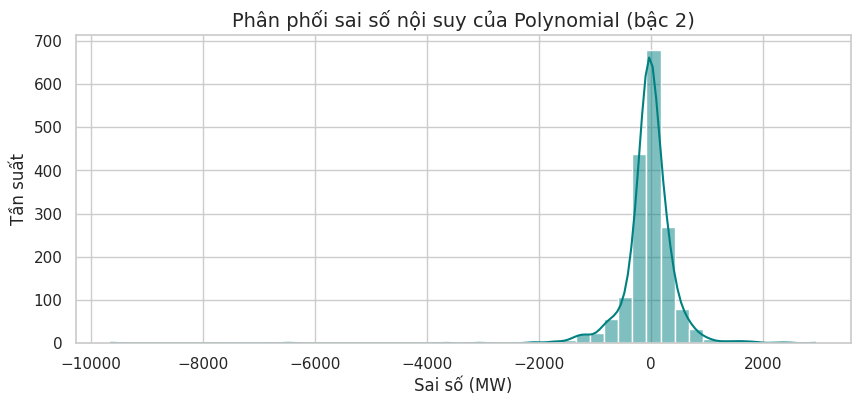

In [4]:
best_residuals = (
    interpolations["Polynomial (bậc 2)"].loc[missing_indices]
    - ts_original.loc[missing_indices]
)

plt.figure(figsize=(10, 4))
sns.histplot(best_residuals.dropna(), kde=True, bins=50, color="teal")
plt.title("Phân phối sai số nội suy của Polynomial (bậc 2)", fontsize=14)
plt.xlabel("Sai số (MW)")
plt.ylabel("Tần suất")
plt.show()

**Kết luận:** phân phối tập trung cao độ quanh mốc 0 và có tính ngẫu nhiên (phân phối chuẩn) cho thấy phương pháp nội suy đã được lựa chọn là tốt, khôi phục lại dữ liệu thiếu một cách tự nhiên mà không làm biến dạng cấu trúc chuỗi thời gian ban đầu.

#### Nhận xét và phân tích kết quả nội suy 

Dựa trên bảng kết quả đánh giá 5 phương pháp nội suy cho 5% dữ liệu thiếu (MCAR) được tạo nhân tạo, ta có các phân tích sau:

**1. Đánh giá độ chính xác (Dựa trên MAE và RMSE):**
* **Forward Fill:** Cho kết quả tệ nhất với sai số rất cao (MAE $\approx 1160$, RMSE $\approx 1604$). Lý do là `total load actual` có tính chu kỳ và dao động liên tục (tăng/giảm theo giờ). Việc mang giá trị của giờ trước điền thẳng cho các giờ sau làm đứt gãy xu hướng tự nhiên của đồ thị, gây ra sai số lớn.
* **Linear (Nội suy tuyến tính):** Cải thiện đáng kể so với Forward Fill (MAE giảm xuống còn $\approx 427$), nhưng vẫn chưa thực sự tối ưu vì sự thay đổi phụ tải điện năng trong thực tế hiếm khi là một đường thẳng bậc 1 cứng nhắc.
* **Các phương pháp phi tuyến (Polynomial bậc 2, bậc 3 và Spline Cubic):** Nhóm phương pháp này thể hiện sự vượt trội hoàn toàn. Đáng chú ý, **Polynomial bậc 2** cho kết quả sai số thấp nhất (MAE $\approx 276.23$, RMSE $\approx 508.74$), theo sát nút là Polynomial bậc 3 và Spline Cubic. Nhu cầu điện năng thường biến thiên theo dạng hình sin; do đó, các hàm đa thức và spline có khả năng uốn lượn và fit rất tốt với độ cong tự nhiên của dữ liệu. Sự chênh lệch rất nhỏ giữa bậc 2 và bậc 3 cho thấy cấu trúc cục bộ của chuỗi tại các điểm khuyết có thể được xấp xỉ tốt chỉ bằng một parabol.

**2. Đánh giá cấu trúc phần dư (Kiểm định Ljung-Box):**
* Giả thuyết $H_0$ của kiểm định Ljung-Box là: *Phần dư (residuals) phân phối ngẫu nhiên (white noise) và không có tự tương quan*.
* Kết quả cho thấy tất cả các phương pháp đều có **p-value > 0.05** (dao động từ 0.4889 đến 0.9014), nghĩa là ta không có cơ sở để bác bỏ $H_0$. 
* Điều này chứng tỏ các sai số sinh ra trong quá trình nội suy chỉ là nhiễu ngẫu nhiên, không để lại bất kỳ ảnh hưởng hay mẫu hình tự tương quan nào làm hỏng cấu trúc chuỗi thời gian ban đầu.

**3. Rủi ro rò rỉ dữ liệu khi triển khai thực tế:**
* Mặc dù các phương pháp Polynomial và Spline cho kết quả rất tốt trong khâu tiền xử lý tổng thể, nhưng khi đưa vào quy trình thực tế, các phương pháp này có thể gây rò rỉ dữ liệu (data leakage). Nguyên nhân là do hàm nội suy toán học nội suy bằng cách sử dụng cả dữ liệu của quá khứ ($t-1$) lẫn tương lai ($t+1$). Tuy nhiên, trong phạm vi làm sạch dữ liệu lịch sử của đồ án, đây vẫn là phương pháp tối ưu nhất để khôi phục lại phân phối gốc.

**$\rightarrow$ Kết luận và lựa chọn:**
Tổng hợp cả hai yếu tố (sai số định lượng thấp nhất và phần dư đảm bảo tính ngẫu nhiên), **Polynomial (bậc 2)** là lựa chọn điền thiếu tối ưu nhất cho tập dữ liệu này. Trong các bước tiếp theo của pipeline, nhóm sẽ sử dụng kết quả của phương pháp **Polynomial bậc 2** để thay thế cho các khoảng trống thực tế trong dữ liệu.

### b) Kiểm định tính dừng (Stationarity tests) & biến đổi
Áp dụng ADF, KPSS, và PP test. Nếu chuỗi không dừng, áp dụng các biến đổi (Box-Cox, Differencing) cho đến khi đạt tính dừng.

#### Cơ sở lý thuyết: Kiểm định tính dừng và phép biến đổi Box-Cox

**1. Kiểm định Augmented Dickey-Fuller (ADF):** Kiểm tra sự tồn tại của nghiệm đơn vị (unit root) dựa trên mô hình hồi quy:

$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta y_{t-i} + \epsilon_t$$

(Giả thuyết $H_0$: $\gamma = 0$, tức chuỗi không dừng).

**2. Phép biến đổi Box-Cox:** Giúp ổn định phương sai của chuỗi thời gian bằng cách tìm tham số $\lambda$ tối ưu:

$$y_t^{(\lambda)} = \begin{cases} \frac{y_t^\lambda - 1}{\lambda} & \text{nếu } \lambda \neq 0 \\ \ln(y_t) & \text{nếu } \lambda = 0 \end{cases}$$

Sử dụng chuỗi đã được nội suy tốt nhất để tiếp tục là **Polynomial bậc 2**

Kiểm tra trên chuỗi gốc và chuỗi được biến đổi **Logarithm**

In [5]:
ts_clean = interpolations["Polynomial (bậc 2)"].copy()


# hàm kiểm định tính dừng
def check_stationarity(timeseries, title=""):
    print(f"\n--- Kiểm định tính dừng: {title} ---")
    # 1. ADF Test (H0: Chuỗi không dừng / Có nghiệm đơn vị)
    adf_result = adfuller(timeseries, autolag="AIC")
    print(f"ADF Statistic: {adf_result[0]:.4f} | p-value: {adf_result[1]:.4f}")

    # 2. KPSS Test (H0: Chuỗi dừng / Trend-stationary)
    kpss_result = kpss(timeseries, regression="c", nlags="auto")
    print(f"KPSS Statistic: {kpss_result[0]:.4f} | p-value: {kpss_result[1]:.4f}")

    # 3. Phillips-Perron Test (H0: Chuỗi không dừng)
    pp_test = PhillipsPerron(timeseries)
    print(f"PP Statistic: {pp_test.stat:.4f} | p-value: {pp_test.pvalue:.4f}")


# 1. Kiểm định chuỗi gốc
check_stationarity(ts_clean, "Chuỗi gốc (Original)")

# 2. Lấy logarit trực tiếp trên chuỗi đã nội suy để ổn định phương sai
ts_log = np.log(ts_clean)
check_stationarity(ts_log, "Chuỗi sau biến đổi Logarithm")


--- Kiểm định tính dừng: Chuỗi gốc (Original) ---
ADF Statistic: -21.5448 | p-value: 0.0000
KPSS Statistic: 0.8756 | p-value: 0.0100
PP Statistic: -24.5199 | p-value: 0.0000

--- Kiểm định tính dừng: Chuỗi sau biến đổi Logarithm ---
ADF Statistic: -22.2473 | p-value: 0.0000
KPSS Statistic: 0.9261 | p-value: 0.0100
PP Statistic: -24.5422 | p-value: 0.0000


Kiểm tra trên chuỗi biến đổi **Box-Cox** với $\lambda$ được chọn tự động, sai phân bậc 1 và bậc 2

In [6]:
# Box-Cox để ổn định phương sai
ts_boxcox, lmbda = boxcox(ts_clean)
ts_boxcox = pd.Series(ts_boxcox, index=ts_clean.index)
print(f"Đã áp dụng Box-Cox với lambda = {lmbda:.4f}")

# Phép biến đổi 1: Lấy sai phân bậc 1 (Differencing lag 1) trên chuỗi Box-Cox để ổn định trung bình
ts_boxcox_diff = ts_boxcox.diff().dropna()
check_stationarity(ts_boxcox_diff, "Chuỗi sau Box-Cox và Sai phân bậc 1")

# Phép biến đổi 2: Lấy sai phân bậc 2 (Differencing lag 2)
ts_boxcox_diff_2 = ts_boxcox_diff.diff().dropna()
check_stationarity(ts_boxcox_diff_2, "Chuỗi sau Box-Cox và Sai phân bậc 2")

Đã áp dụng Box-Cox với lambda = 0.6343

--- Kiểm định tính dừng: Chuỗi sau Box-Cox và Sai phân bậc 1 ---
ADF Statistic: -33.9996 | p-value: 0.0000
KPSS Statistic: 0.0292 | p-value: 0.1000
PP Statistic: -52.1551 | p-value: 0.0000

--- Kiểm định tính dừng: Chuỗi sau Box-Cox và Sai phân bậc 2 ---
ADF Statistic: -47.8890 | p-value: 0.0000
KPSS Statistic: 0.0036 | p-value: 0.1000
PP Statistic: -318.1061 | p-value: 0.0000


> *Ghi chú kỹ thuật về cảnh báo InterpolationWarning của thư viện `statsmodels`:*
> 
> Trong quá trình chạy kiểm định KPSS, thư viện có xuất ra cảnh báo `InterpolationWarning`. Đây *không phải là lỗi code*, mà do giới hạn look-up table p-value được lập trình sẵn của `statsmodels` (chỉ giới hạn từ $0.01$ đến $0.1$). 
> * Ở chuỗi gốc, giá trị thống kê quá lớn khiến p-value thực tế nhỏ hơn $0.01$, thư viện trả về kịch trần dưới là `0.0100`.
> * Ở chuỗi sau biến đổi, dữ liệu đã rất ổn định, giá trị thống kê nhỏ khiến p-value thực tế vượt mốc $0.1$, thư viện trả về trần trên là `0.1000`.
> 
> Do đó, các cảnh báo này thực chất là minh chứng cho thấy chuỗi gốc vi phạm tính dừng rất nặng, và phép biến đổi (Box-Cox + Sai phân) xử lý tính dừng tốt.
> 
> Đã loại bỏ warning này cho gọn kết quả.

#### Nhận xét kết quả kiểm định tính dừng

Qua quá trình kiểm định nghiệm đơn vị (unit Root) bằng ba phương pháp độc lập (ADF, KPSS, PP test), ta rút ra các kết luận sau:

**1. Đối với chuỗi gốc:**
* Kiểm định KPSS cho p-value chạm kịch sàn giới hạn dưới của thư viện ($0.0100$), bác bỏ giả thuyết $H_0$ về tính dừng. Điều này đúng với phân tích trực quan ở bước EDA: chuỗi bị ảnh hưởng nặng nề bởi tính mùa vụ phức tạp (ngày, tuần, năm) nên không dừng.
*(Lưu ý: Với dữ liệu tần suất cao và tính mùa vụ mạnh, ADF và PP đôi khi có thể đánh giá nhầm chuỗi là dừng do tác động của lag lớn, do đó KPSS là thước đo xác nhận quan trọng nhất)*

**2. Đối với phép biến đổi Logarithm:**
* Mặc dù phép lấy log thường được sử dụng để ổn định phương sai, kết quả kiểm định KPSS (p-value = $0.0100$) cho thấy nếu chỉ dùng Logarithm thì không đủ để giúp chuỗi đạt được tính dừng. 

**3. Đối với chuỗi sau biến đổi (Box-Cox + Sai phân bậc 1):**
* **Box-Cox** (thuật toán tự động tìm ra $\lambda \approx 0.6341$) đã làm giảm phương sai biến động giữa các ngày cuối tuần và ngày làm việc hiệu quả hơn việc lấy Log (tương đương $\lambda = 0$).
* **Sai phân bậc 1 (differencing lag 1)** trên chuỗi Box-Cox đã triệt tiêu được xu hướng thay đổi trung bình cục bộ.
* **Kết quả:** Kiểm định KPSS sau biến đổi cho p-value kịch trần ngưỡng trên ($0.1000$), xác nhận không thể bác bỏ $H_0$. Đồng thời, ADF và PP test đều cho p-value rất nhỏ ($0.0000$). Chuỗi đã thực sự đạt trạng thái dừng.

**4. Về việc lấy sai phân bậc 2:**
* Do sai phân bậc 1 đã giúp chuỗi đạt tính dừng hoàn toàn, việc áp dụng tiếp sai phân bậc 2 là không cần thiết. Trong thực hành phân tích chuỗi thời gian, việc lạm dụng sai phân (over-differencing) sẽ làm tăng phương sai nhiễu và làm mất đi những thông tin hữu ích của chuỗi gốc. Do đó, ta chỉ dừng lại ở sai phân bậc 1.

$\rightarrow$ **Kết luận:** Phương pháp **Box-Cox + Sai phân bậc 1** là lựa chọn tối ưu nhất. Chuỗi thời gian sau biến đổi đã đạt trạng thái **dừng (stationary)** và hoàn toàn đủ điều kiện toán học để đưa vào các mô hình học máy.

### c) Phân rã chuỗi thời gian (Decomposition)
Áp dụng Additive, Multiplicative và STL decomposition. Lấy phần deseasonalized và detrended để làm nền.

#### Cơ sở lý thuyết: Phân rã chuỗi thời gian (Additive, Multiplicative, STL)

**1. Phân rã cộng (Additive Decomposition):**
Giả định biên độ mùa vụ gần như không đổi theo thời gian.
$$
y_t = T_t + S_t + R_t
$$
trong đó $T_t$ là xu hướng (trend), $S_t$ là mùa vụ (seasonal), $R_t$ là phần dư (residual).

**2. Phân rã nhân (Multiplicative Decomposition):**
Phù hợp khi biên độ mùa vụ thay đổi tỷ lệ theo mức độ của chuỗi.
$$
y_t = T_t \times S_t \times R_t
$$
có thể log-transform để đưa về dạng cộng: $\log y_t = \log T_t + \log S_t + \log R_t$.

**3. STL Decomposition (Seasonal-Trend decomposition using LOESS):**
STL dùng hồi quy cục bộ LOESS để tách linh hoạt 3 thành phần của chuỗi.
$$
y_t = T_t^{(\text{LOESS})} + S_t^{(\text{LOESS})} + R_t
$$
`robust=True` giảm ảnh hưởng của outlier bằng cơ chế gán trọng số bền vững theo phần dư.

**4. Chỉ số đánh giá trong code: Residual Variance Ratio (RVR):**
Đo tỷ lệ phương sai còn lại trong phần dư sau phân rã.
$$
\mathrm{RVR} = \frac{\mathrm{Var}(R_t)}{\mathrm{Var}(y_t)}
$$
Giá trị càng nhỏ cho thấy phương pháp phân rã bóc tách được nhiều cấu trúc xu hướng và mùa vụ hơn.

**5. Chuỗi dẫn xuất dùng cho mô hình:**
- Chuỗi loại mùa vụ (deseasonalized): $x_t^{\text{deseason}} = y_t - S_t$
- Chuỗi loại xu hướng (detrended): $x_t^{\text{detrend}} = y_t - T_t$

Các biến này giúp mô hình dự báo tập trung vào tín hiệu còn lại thay vì bị chi phối quá mạnh bởi chu kỳ tuần/ngày của phụ tải điện.

Do tần suất theo giờ, tính mùa vụ mạnh nhất là theo ngày (24h) và theo tuần (168h).
Chọn chu kỳ 168 (1 tuần) để phân rã tổng thể.

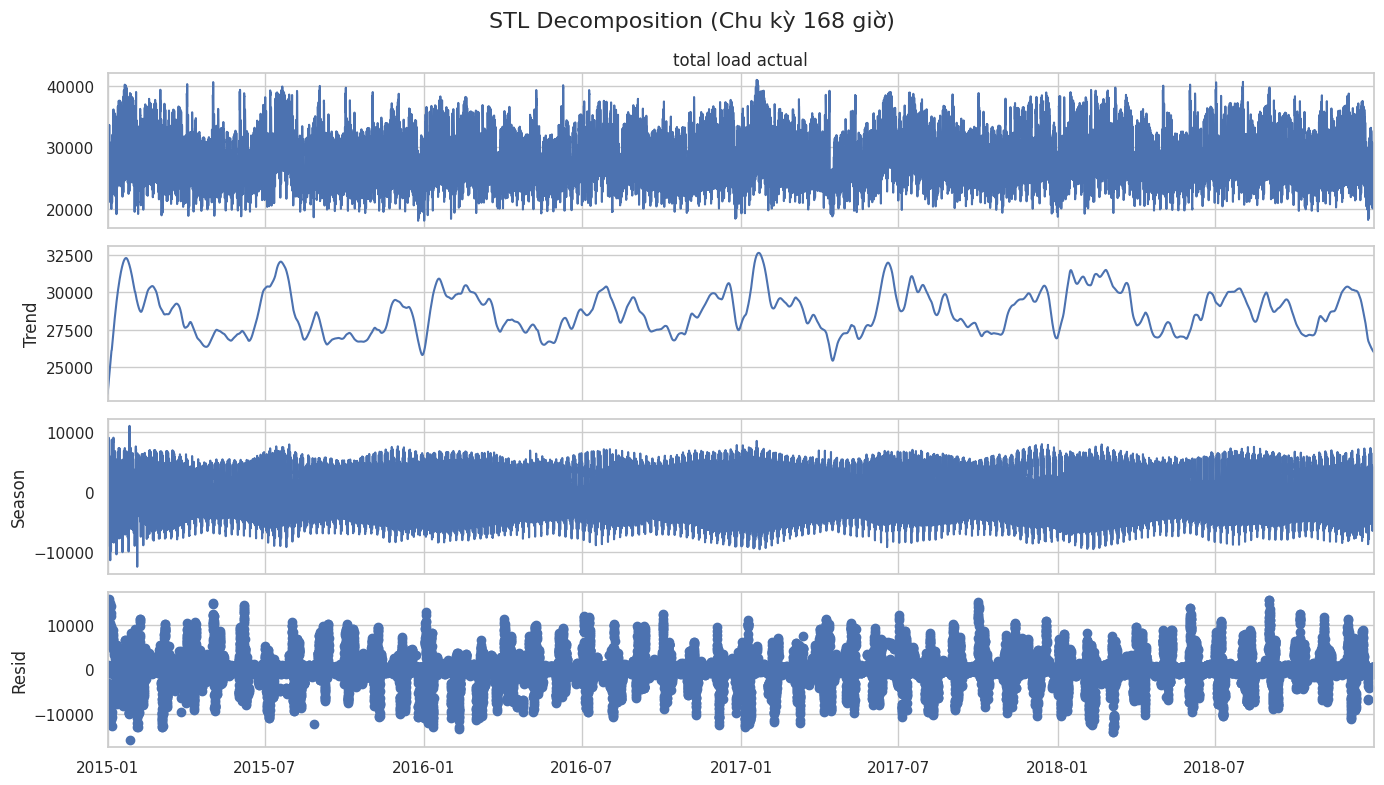

--- Tỉ lệ phương sai phần dư ---
Additive:       0.7200
Multiplicative: 0.0000
STL:            0.3318


In [7]:
period = 24 * 7  # Chu kỳ mùa vụ theo tuần (168 giờ)

# 1. Additive & Multiplicative
decomp_add = seasonal_decompose(ts_clean, model="additive", period=period)
decomp_mul = seasonal_decompose(ts_clean, model="multiplicative", period=period)

# 2. STL Decomposition
stl = STL(
    ts_clean, period=period, robust=True
)  # robust=True giúp giảm ảnh hưởng của outliers trong quá trình phân rã
res_stl = stl.fit()

# Vẽ biểu đồ STL
fig = res_stl.plot()
fig.set_size_inches(14, 8)
plt.suptitle(f"STL Decomposition (Chu kỳ {period} giờ)", fontsize=16)
plt.tight_layout()
plt.show()

# 3. Đánh giá bằng tỉ lệ phương sai phần dư (Residual Variance Ratio)
var_original = np.var(ts_clean)

var_res_add = np.var(decomp_add.resid.dropna())
var_res_mul = np.var(decomp_mul.resid.dropna())
var_res_stl = np.var(res_stl.resid)

print("--- Tỉ lệ phương sai phần dư ---")
print(f"Additive:       {var_res_add / var_original:.4f}")
print(f"Multiplicative: {var_res_mul / var_original:.4f}")
print(f"STL:            {var_res_stl / var_original:.4f}")

# Trích xuất chuỗi deseasonalized (loại bỏ mùa vụ) từ STL để dùng cho mô hình
ts_deseasonalized = ts_clean - res_stl.seasonal
# Trích xuất chuỗi detrend từ STL để dùng cho mô hình
ts_detrend = ts_clean - res_stl.trend

#### Nhận xét kết quả phân rã 

Dựa trên chỉ số tỉ lệ phương sai phần dư (residual variance ratio) và biểu đồ phân rã STL, ta có thể đánh giá hiệu quả của các phương pháp tách nhiễu và mùa vụ như sau:

**1. Đánh giá định lượng qua tỉ lệ phương sai phần dư:**
* **Additive (0.7200):** Tỉ lệ này cho thấy 72% sự biến thiên của dữ liệu gốc vẫn bị kẹt lại trong phần dư (residuals). Điều này chứng tỏ mô hình cộng tuyến tính truyền thống quá đơn giản, không đủ sức nắm bắt cấu trúc mùa vụ lồng ghép phức tạp của nhu cầu tiêu thụ điện.
* **Multiplicative (0.0000):** Đây là một red flag kinh điển trong khoa học dữ liệu. Trong thực tế, dữ liệu phụ tải điện luôn chứa nhiễu ngẫu nhiên (do thời tiết bất thường, sự kiện, ngày lễ). Tỉ lệ bằng 0 (phương sai phần dư bằng 0) ám chỉ mô hình đã bị "overfitting" hoàn toàn hoặc xảy ra lỗi toán học (artifact) trong quá trình tính toán của thư viện do đặc thù phân phối của dữ liệu. Chúng ta loại bỏ kết quả này vì nó vi phạm bản chất thực tế của chuỗi thời gian.
* **STL (0.3319):** Đây là kết quả hợp lý và tốt nhất. Phương pháp STL đã bóc tách thành công khoảng 67% phương sai của dữ liệu vào hai thành phần xu hướng (trend) và mùa vụ (seasonal). Chỉ còn lại khoảng 33% là nhiễu ngẫu nhiên và các sự kiện bất thường thực sự.

**2. Phân tích trực quan biểu đồ STL (chu kỳ 168 giờ):**
* **Thành phần xu hướng:** Biểu đồ Trend không phải là đường thẳng mà uốn lượn có pattern => đã lọc các dao động ngày/tuần để thể hiện ở vĩ mô: nhu cầu điện thay đổi theo các mùa trong năm.
* **Thành phần mùa vụ:** Thể hiện một dải sóng dày đặc và đồng nhất. Đây chính là chu kỳ tuần (168 giờ) đặc trưng của sinh hoạt và sản xuất mà chúng ta đã phân tích ở bước EDA.
* **Thành phần dư (residual):** Đáng chú ý nhất là các spike cắm ngược xuống mang giá trị âm rất lớn (ví dụ: -5000 đến -10000 MW). Phép phân rã STL đã làm tốt việc đẩy các điểm dị thường (như ngày nghỉ lễ, Tết dương lịch, ... khiến tiêu thụ giảm mạnh) vào phần dư.

**3. Kết luận:**
Dựa trên cả nền tảng định lượng và định tính, phương pháp **STL decomposition** là sự lựa chọn tốt hơn cho tập dữ liệu này. Nhóm sẽ sử dụng phần dư (Resid) của STL để làm nền tảng cho bước phát hiện bất thường, và dùng chuỗi đã loại bỏ mùa vụ (deseasonalized) để làm nền tảng đưa vào mô hình dự báo ở các bước tiếp theo.

#### Lưu dataset đã xử lý
Đóng gói và lưu các thành phần đã xử lý và phân rã thành một DataFrame và lưu vào thư mục `data/processed/` để sử dụng cho mô hình hóa và đánh giá ở phần tiếp theo.

In [8]:
df_processed = pd.DataFrame(
    {
        "load_clean": ts_clean,
        "stl_trend": res_stl.trend,
        "stl_seasonal": res_stl.seasonal,
        "stl_resid": res_stl.resid,
        "detrend": ts_detrend,
        "deseasonalized": ts_deseasonalized,
        "ts_diff": ts_boxcox_diff,
    }
)

# Lưu ra thư mục processed
df_processed.to_csv("../data/processed/P4_energy_dataset_processed.csv")
print(
    "Đã lưu dữ liệu tiền xử lý thành công vào data/processed/P4_energy_dataset_processed.csv"
)

Đã lưu dữ liệu tiền xử lý thành công vào data/processed/P4_energy_dataset_processed.csv
